# Commodity forecasting | Data and prediction contract

A research project built around 424 multi-horizon return targets from LME, JPX, US equities, and FX. This notebook establishes what can be known at prediction time and which data is reserved for final evaluation.

**Research question:** can economically motivated representations improve stable cross-sectional return ranking?

[Dataset](https://www.kaggle.com/competitions/mitsui-commodity-prediction-challenge/data) · [Official target construction](https://www.kaggle.com/code/sohier/mitsui-target-calculation-example/) · Next: `01_eda.ipynb`.

In [1]:
from pathlib import Path
import sys
if not Path("pyproject.toml").exists():
    sys.path.insert(0, str(Path.cwd().parent))
import json
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, Markdown
from scripts.notebook_support import project_root, checked_reports, checked_study, checked_domain, checked_attribution, show_figure
root = project_root()
audit, research = checked_reports(root)
study = checked_study(root)
domain = checked_domain(root)
attribution = checked_attribution(root)
study_config = json.loads((root / "configs/feature_study.json").read_text())
config = json.loads((root / "configs/research.json").read_text())
display(Markdown(f"**Verified domain attribution:** `{attribution['lineage'][:16]}` · **Feature gate:** open · Previous studies preserved"))

**Verified domain attribution:** `b6914cbaeb452984` · **Feature gate:** open · Previous studies preserved

In [2]:
from commodity_prediction.data import load_data
from commodity_prediction.studies.run import study_folds
x, y, pairs = load_data(root)
folds, development_stop = study_folds(len(x), config, study_config)
inventory = pd.DataFrame({"Measure": ["Observed dates", "Input columns", "Return targets", "Development dates", "Nominally reserved dates", "Untouched final-test dates"],
                          "Count": [len(x), x.shape[1], y.shape[1], development_stop, len(x) - development_stop, 247]})
display(inventory.set_index("Measure"))

,Count
Measure,
Observed dates,1961
Input columns,557
Return targets,424
Development dates,1709
Nominally reserved dates,252
Untouched final-test dates,247


## The target starts after the current date

For an asset with price $P$ and horizon $h$, the target at date $t$ is $\log(P_{t+h+1}/P_{t+1})$. For a pair, subtract the second asset's return. Current-row market observations are available before prediction. Labels become available at $t+h+1$.

This is why a one-day target needs a two-date availability delay. Shifting targets by only the stated horizon would leak information.

In [3]:
release = pd.DataFrame({"Horizon": [1, 2, 3, 4], "Label release delay": [2, 3, 4, 5], "Targets": [int((pairs.lag == h).sum()) for h in range(1, 5)]})
display(release.set_index("Horizon"))
display(Markdown(f"Target reconstruction compared **{audit['target_reconstruction_compared_values']:,}** observable development labels. Maximum absolute difference: **{audit['target_reconstruction_max_absolute_error']:.2e}**, below the 1e-5 rounding tolerance."))

,Label release delay,Targets
Horizon,,
1,2,106
2,3,106
3,4,106
4,5,106


Target reconstruction compared **647,595** observable development labels. Maximum absolute difference: **3.22e-15**, below the 1e-5 rounding tolerance.

## Protect 247 final-test dates and the boundary buffer

Three expanding walk-forward folds use 180, 180, and 175 validation dates. A five-date terminal embargo ensures every validation target is fully observable before the reserved interval begins. Five dates are purged before every validation block, so all fitting labels were released strictly before its first prediction. All 252 nominally reserved origins remain outside development. The initial evaluation already inspected overlapping forward outcomes through date 1713, so origins 1709–1713 are a permanent buffer. Only origins 1714–1960 (247 dates) qualify for the eventual untouched final test. The downloadable mock test file overlaps training and is not a valid holdout.

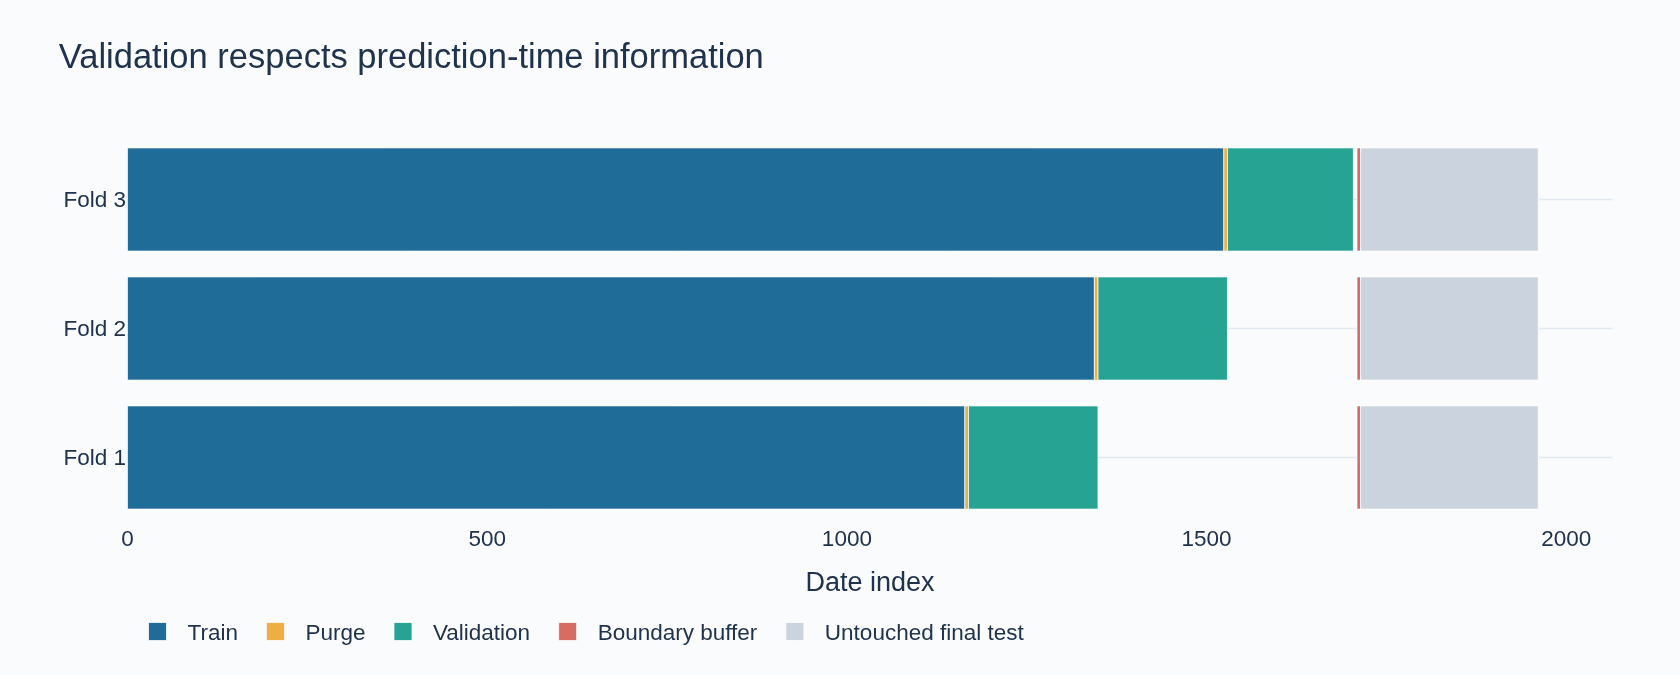

In [4]:
fig = go.Figure()
for fold in folds:
    label = f"Fold {fold.number + 1}"
    for part, start, length, color in [
        ("Train", 0, fold.train_stop, "#1F6C99"),
        ("Purge", fold.train_stop, fold.validation_start - fold.train_stop, "#EDAF43"),
        ("Validation", fold.validation_start, fold.validation_stop - fold.validation_start, "#27A394"),
        ("Boundary buffer", development_stop, 5, "#D76C64"),
        ("Untouched final test", development_stop + 5, len(x) - development_stop - 5, "#CAD3DE")]:
        fig.add_trace(go.Bar(x=[length], y=[label], base=start, orientation="h", name=part,
                             marker_color=color, showlegend=fold.number == 0))
fig.update_layout(barmode="overlay", title="Validation respects prediction-time information", xaxis_title="Date index", legend={"orientation": "h", "y": -0.22})
show_figure(fig, root, "validation_protocol", 450)

## Reproducibility and data handling

The public repository contains source, aggregate evidence, and executed notebooks. Raw market rows, labels, and model predictions remain in private storage under the competition's data-use terms. A data/source/configuration fingerprint connects every downstream result. Missing, changed, or corrupt checkpoints cause a clear failure rather than silent reuse.

**Status:** data contract verified. Feature research is in progress; final evaluation has not run.